# Notebook 2: Pooled Multi-Flow Regression Analysis (v2b)
## Hurricane Mobility Disruption — Cross-Hurricane Socioeconomic Regression

**Objective**: Pool both hurricanes (Milton + Helene) and run OLS regressions with socioeconomic controls and a hurricane dummy for each dependent variable.

**Dependent Variables (5 DV keys)**:
- `largest_drop_within` — max % reduction from SARIMA baseline (within-region flow)
- `largest_drop_inflow` — max % reduction from SARIMA baseline (inflow)
- `outflow_increase` — max % increase above SARIMA baseline (outflow, evacuation surge)
- `recovery_within` — Theil-Sen trend-based recovery time in days (within-region)
- `recovery_inflow` — Theil-Sen trend-based recovery time in days (inflow)

**Independent Variables**:
- 4 socioeconomic features (standardized): total_population, median_household_income, pct_no_vehicle, insurance_coverage_pct
- Hurricane dummy: `hrc_dummy` (1=Milton, 0=Helene) — raw, not standardized

**Model**: `DV ~ β₀ + β₁·pop_z + β₂·income_z + β₃·novehicle_z + β₄·insurance_z + β₅·hrc_dummy + ε`

**Design**: Each regression pools both hurricanes (~258–292 counties). 5 regressions total.

**Diagnostics**: VIF, residual plots, Breusch-Pagan, Shapiro-Wilk, Durbin-Watson

**Outputs**: `../results/regression/` — regression summaries, coefficients, comparison tables, figures

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.preprocessing import StandardScaler
import censusdata

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# ── Configuration ──

HURRICANES = {
    "milton": {
        "landing_date": pd.Timestamp("2024-10-09"),
        "data_dir": "../results/milton/",
        "dummy": 1,
    },
    "helene": {
        "landing_date": pd.Timestamp("2024-09-26"),
        "data_dir": "../results/helene/",
        "dummy": 0,
    },
}

# 5 DV keys — each will be loaded, merged with ACS, and regressed
DV_CONFIGS = {
    "largest_drop_within": {
        "csv": "largest_drop_within.csv",
        "dv_col": "largest_drop",
        "label": "Largest Drop \u2014 Within (%)",
        "unit": "%",
    },
    "largest_drop_inflow": {
        "csv": "largest_drop_inflow.csv",
        "dv_col": "largest_drop",
        "label": "Largest Drop \u2014 Inflow (%)",
        "unit": "%",
    },
    "outflow_increase": {
        "csv": "outflow_increase.csv",
        "dv_col": "largest_increase",
        "label": "Outflow Increase (%)",
        "unit": "%",
    },
    "recovery_within": {
        "csv": "recovery_within.csv",
        "dv_col": "recovery_days",
        "label": "Recovery Time \u2014 Within (days)",
        "unit": "days",
    },
    "recovery_inflow": {
        "csv": "recovery_inflow.csv",
        "dv_col": "recovery_days",
        "label": "Recovery Time \u2014 Inflow (days)",
        "unit": "days",
    },
}

# Socioeconomic features per CLAUDE.md 6.2
FEATURES = [
    "total_population",
    "median_household_income",
    "pct_no_vehicle",
    "insurance_coverage_pct",
]

# Shared output directory for pooled regressions
OUTPUT_DIR = "../results/regression/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)

print(f"Configured {len(DV_CONFIGS)} DV keys: {list(DV_CONFIGS.keys())}")
print(f"Features: {FEATURES}")
print(f"Output directory: {OUTPUT_DIR}")

Configured 5 DV keys: ['largest_drop_within', 'largest_drop_inflow', 'outflow_increase', 'recovery_within', 'recovery_inflow']
Features: ['total_population', 'median_household_income', 'pct_no_vehicle', 'insurance_coverage_pct']
Output directory: ../results/regression/


## 1. Load Dependent Variable Data (Pooled Across Hurricanes)

In [3]:
def load_dv_data(dv_key):
    """
    Load DV data for a given key, pooling both hurricanes.

    For each hurricane, reads the CSV, tags with hrc_name and hrc_dummy,
    then concatenates. Gracefully skips if CSV not found.

    Returns
    -------
    df : DataFrame with columns [GEOID, <dv_col>, ..., hrc_name, hrc_dummy]
    """
    cfg = DV_CONFIGS[dv_key]
    csv_name = cfg["csv"]
    dv_col = cfg["dv_col"]

    frames = []
    for hrc_name, hrc_cfg in HURRICANES.items():
        path = os.path.join(hrc_cfg["data_dir"], csv_name)

        if not os.path.exists(path):
            print(f"  WARNING: {path} not found, skipping {hrc_name}")
            continue

        df = pd.read_csv(path)
        df["GEOID"] = df["GEOID"].astype(int)
        df["hrc_name"] = hrc_name
        df["hrc_dummy"] = hrc_cfg["dummy"]

        n_valid = df[dv_col].notna().sum()
        print(f"  Loaded {hrc_name}: {len(df)} counties, {n_valid} with valid {dv_col}")
        frames.append(df)

    if not frames:
        return None

    combined = pd.concat(frames, ignore_index=True)
    print(f"  Combined: {len(combined)} total rows ({combined[dv_col].notna().sum()} valid)")
    return combined

In [4]:
dv_data = {}

for dv_key in DV_CONFIGS:
    cfg = DV_CONFIGS[dv_key]
    print(f"\n{'='*60}")
    print(f"Loading: {dv_key} ({cfg['label']})")
    print(f"{'='*60}")

    df = load_dv_data(dv_key)
    if df is not None:
        dv_data[dv_key] = df
        dv_col = cfg["dv_col"]
        print(f"\n{dv_key} per-hurricane summary:")
        display(df.groupby("hrc_name")[dv_col].describe())
    else:
        print(f"SKIPPED: No data found for {dv_key}")

print(f"\n\nSuccessfully loaded {len(dv_data)}/{len(DV_CONFIGS)} DV keys: {list(dv_data.keys())}")


Loading: largest_drop_within (Largest Drop — Within (%))
  Loaded milton: 21 counties, 21 with valid largest_drop
  Loaded helene: 271 counties, 237 with valid largest_drop
  Combined: 292 total rows (258 valid)

largest_drop_within per-hurricane summary:


,count,mean,std,min,25%,50%,75%,max
hrc_name,,,,,,,,
helene,237.0,-18.518508,7.632382,-50.411748,-21.921699,-17.324367,-13.496398,-0.566433
milton,21.0,-35.033678,6.510959,-47.237604,-40.776471,-35.214422,-30.990315,-23.527618



Loading: largest_drop_inflow (Largest Drop — Inflow (%))
  Loaded milton: 21 counties, 11 with valid largest_drop
  Loaded helene: 271 counties, 233 with valid largest_drop
  Combined: 292 total rows (244 valid)

largest_drop_inflow per-hurricane summary:


,count,mean,std,min,25%,50%,75%,max
hrc_name,,,,,,,,
helene,233.0,-36.289245,19.844569,-100.000000,-47.546684,-33.670193,-22.508677,14.946039
milton,11.0,-410.053609,1190.006517,-3995.607476,-68.232568,-51.391211,-31.054100,5.345929



Loading: outflow_increase (Outflow Increase (%))
  Loaded milton: 21 counties, 21 with valid largest_increase
  Combined: 21 total rows (21 valid)

outflow_increase per-hurricane summary:


...


Loading: recovery_within (Recovery Time — Within (days))
  Loaded milton: 21 counties, 21 with valid recovery_days
  Combined: 21 total rows (21 valid)

recovery_within per-hurricane summary:


,count,mean,std,min,25%,50%,75%,max
hrc_name,,,,,,,,
milton,21.0,4.868708,0.48975,4.143078,4.553001,4.801458,5.098491,6.219785



Loading: recovery_inflow (Recovery Time — Inflow (days))
  Loaded milton: 21 counties, 9 with valid recovery_days
  Combined: 21 total rows (9 valid)

recovery_inflow per-hurricane summary:


,count,mean,std,min,25%,50%,75%,max
hrc_name,,,,,,,,
milton,9.0,5.799817,3.437048,1.703514,4.593638,4.931437,6.38983,12.703205




Successfully loaded 5/5 DV keys: ['largest_drop_within', 'largest_drop_inflow', 'outflow_increase', 'recovery_within', 'recovery_inflow']


## 2. Socioeconomic Data Integration (ACS)

In [5]:
ACS_VARS = [
    "B01003_001E",   # Total population
    "B19013_001E",   # Median household income
    "B08201_001E",   # Total households (vehicle denom)
    "B08201_002E",   # Households with no vehicle
    "B27010_001E",   # Total civilian noninstitutionalized population (insurance universe)
    "B27010_017E",   # No health insurance coverage
]

acs_cache = "acs_socioeconomic_v2.csv"

if os.path.exists(acs_cache):
    print(f"Loading cached ACS data from {acs_cache}")
    acs_df = pd.read_csv(acs_cache)
    acs_df["GEOID"] = acs_df["GEOID"].astype(int)
else:
    print("Downloading ACS 5-year (2022) data for all US counties...")
    acs_raw = censusdata.download(
        "acs5", 2022,
        censusdata.censusgeo([("county", "*")]),
        ACS_VARS,
    )
    print(f"Downloaded {len(acs_raw)} counties")

    acs_raw = acs_raw.rename(columns={
        "B01003_001E": "total_population",
        "B19013_001E": "median_household_income",
        "B08201_001E": "total_households",
        "B08201_002E": "no_vehicle_households",
        "B27010_001E": "insurance_universe",
        "B27010_017E": "no_insurance_count",
    })

    # Construct integer GEOID
    acs_raw = acs_raw.reset_index()
    acs_raw["GEOID"] = acs_raw["index"].apply(
        lambda g: int(g.params()[0][1] + g.params()[1][1].zfill(3))
    )

    # Filter sentinel values
    acs_raw.loc[acs_raw["median_household_income"] < 0, "median_household_income"] = np.nan

    # Derived variables
    acs_raw["pct_no_vehicle"] = np.where(
        acs_raw["total_households"] > 0,
        (acs_raw["no_vehicle_households"] / acs_raw["total_households"]) * 100,
        np.nan,
    )
    acs_raw["insurance_coverage_pct"] = np.where(
        acs_raw["insurance_universe"] > 0,
        (1 - acs_raw["no_insurance_count"] / acs_raw["insurance_universe"]) * 100,
        np.nan,
    )

    keep_cols = ["GEOID", "total_population", "median_household_income",
                 "pct_no_vehicle", "insurance_coverage_pct"]
    acs_df = acs_raw[keep_cols].copy()

    acs_df.to_csv(acs_cache, index=False)
    print(f"Saved to {acs_cache}")

print(f"ACS data shape: {acs_df.shape}")
print(f"GEOID dtype: {acs_df['GEOID'].dtype}")
display(acs_df.describe())
display(acs_df.head())

Loading cached ACS data from acs_socioeconomic_v2.csv
ACS data shape: (3222, 5)
GEOID dtype: int64


,GEOID,total_population,median_household_income,pct_no_vehicle,insurance_coverage_pct
count,3222.000000,3.222000e+03,3221.000000,3222.000000,3222.000000
mean,31377.890441,1.037771e+05,62326.868053,6.196515,98.479942
std,16299.548258,3.299494e+05,17770.571725,4.537869,1.495355
min,1001.000000,5.000000e+01,14525.000000,0.000000,79.707009
25%,19029.500000,1.103975e+04,51823.000000,3.979928,98.123447
50%,30022.000000,2.591000e+04,60461.000000,5.408898,98.897881
75%,46104.500000,6.737050e+04,70379.000000,7.360328,99.341692
max,72153.000000,9.936690e+06,170463.000000,85.944206,100.000000


,GEOID,total_population,median_household_income,pct_no_vehicle,insurance_coverage_pct
0,1001,58761,68315.0,3.980635,99.521265
1,1003,233420,71039.0,2.264267,98.745621
2,1005,24877,39712.0,11.734694,99.346793
3,1007,22251,50669.0,7.538803,99.582734
4,1009,59077,57440.0,4.841395,99.400891


## 3. Merge DV Data with ACS and Exploratory Data Analysis

In [6]:
def merge_dv_acs(dv_df, acs_df, dv_col):
    """
    Merge DV data with ACS on GEOID, drop rows with missing values.

    Returns
    -------
    merged : DataFrame with DV, ACS features, hrc_name, hrc_dummy
    """
    merged = dv_df.merge(acs_df, on="GEOID", how="inner")

    # Keep only complete cases
    required_cols = [dv_col] + FEATURES + ["hrc_dummy"]
    merged = merged.dropna(subset=required_cols)

    print(f"  After merge + dropna: {len(merged)} counties")
    print(f"  By hurricane:")
    print(merged.groupby("hrc_name")[dv_col].agg(["count", "mean", "std"]).round(2))

    return merged

In [7]:
merged_data = {}

for dv_key, df in dv_data.items():
    cfg = DV_CONFIGS[dv_key]
    dv_col = cfg["dv_col"]

    print(f"\n{'='*60}")
    print(f"Merging: {dv_key} ({cfg['label']})")
    print(f"{'='*60}")

    merged = merge_dv_acs(df, acs_df, dv_col)
    merged_data[dv_key] = merged

print(f"\nMerged datasets: {list(merged_data.keys())}")
for k, v in merged_data.items():
    print(f"  {k}: {len(v)} counties")


Merging: largest_drop_within (Largest Drop — Within (%))
  After merge + dropna: 258 counties
  By hurricane:
          count   mean   std
hrc_name                    
helene      237 -18.52  7.63
milton       21 -35.03  6.51

Merging: largest_drop_inflow (Largest Drop — Inflow (%))
  After merge + dropna: 244 counties
  By hurricane:
          count    mean      std
hrc_name                        
helene      233  -36.29    19.84
milton       11 -410.05  1190.01

Merging: outflow_increase (Outflow Increase (%))
  After merge + dropna: 21 counties
  By hurricane:
          count  mean    std
hrc_name                    
milton       21  61.1  51.38

Merging: recovery_within (Recovery Time — Within (days))
  After merge + dropna: 21 counties
  By hurricane:
          count  mean   std
hrc_name                   
milton       21  4.87  0.49

Merging: recovery_inflow (Recovery Time — Inflow (days))
  After merge + dropna: 9 counties
  By hurricane:
          count  mean   std
hrc_name  

In [8]:
def plot_eda_scatter(reg_df, features, dv_col, dv_key, display_name, output_dir):
    """Scatter plots of each feature vs DV with Pearson/Spearman."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, feat in zip(axes.flat, features):
        ax.scatter(reg_df[feat], reg_df[dv_col], alpha=0.6,
                   edgecolors="k", s=40)
        # Fit line
        z = np.polyfit(reg_df[feat].values, reg_df[dv_col].values, 1)
        p = np.poly1d(z)
        x_range = np.linspace(reg_df[feat].min(), reg_df[feat].max(), 100)
        ax.plot(x_range, p(x_range), "r--", linewidth=1.5)

        # Correlation annotations
        r_p, p_p = stats.pearsonr(reg_df[feat], reg_df[dv_col])
        r_s, p_s = stats.spearmanr(reg_df[feat], reg_df[dv_col])
        ax.set_xlabel(feat)
        ax.set_ylabel(display_name)
        ax.set_title(f"{feat}\nPearson r={r_p:.3f} (p={p_p:.3f}), Spearman rho={r_s:.3f}")
        ax.grid(alpha=0.3)

    fig.suptitle(f"EDA: {display_name} (N={len(reg_df)})",
                 fontsize=14, y=1.01)
    plt.tight_layout()

    fig_dir = os.path.join(output_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)
    plt.savefig(os.path.join(fig_dir, f"eda_scatter_{dv_key}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
def plot_correlation_matrix(reg_df, features, dv_col, dv_key, display_name, output_dir):
    """Correlation heatmap of features + DV + hurricane dummy."""
    fig, ax = plt.subplots(figsize=(9, 7))
    corr_cols = features + [dv_col, "hrc_dummy"]
    corr = reg_df[corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
    ax.set_title(f"Correlation Matrix \u2014 {display_name}")
    plt.tight_layout()

    fig_dir = os.path.join(output_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)
    plt.savefig(os.path.join(fig_dir, f"correlation_matrix_{dv_key}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
def plot_dv_distribution(reg_df, dv_col, dv_key, display_name, output_dir):
    """Histogram of DV with median line."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(reg_df[dv_col], bins=25, edgecolor="black", alpha=0.7)
    median_val = reg_df[dv_col].median()
    ax.axvline(median_val, color="red", ls="--",
               label=f"Median: {median_val:.1f}")
    ax.set_xlabel(display_name)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution \u2014 {display_name} (N={len(reg_df)})")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    fig_dir = os.path.join(output_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)
    plt.savefig(os.path.join(fig_dir, f"distribution_{dv_key}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


EDA: Largest Drop — Within (%) (258 counties)


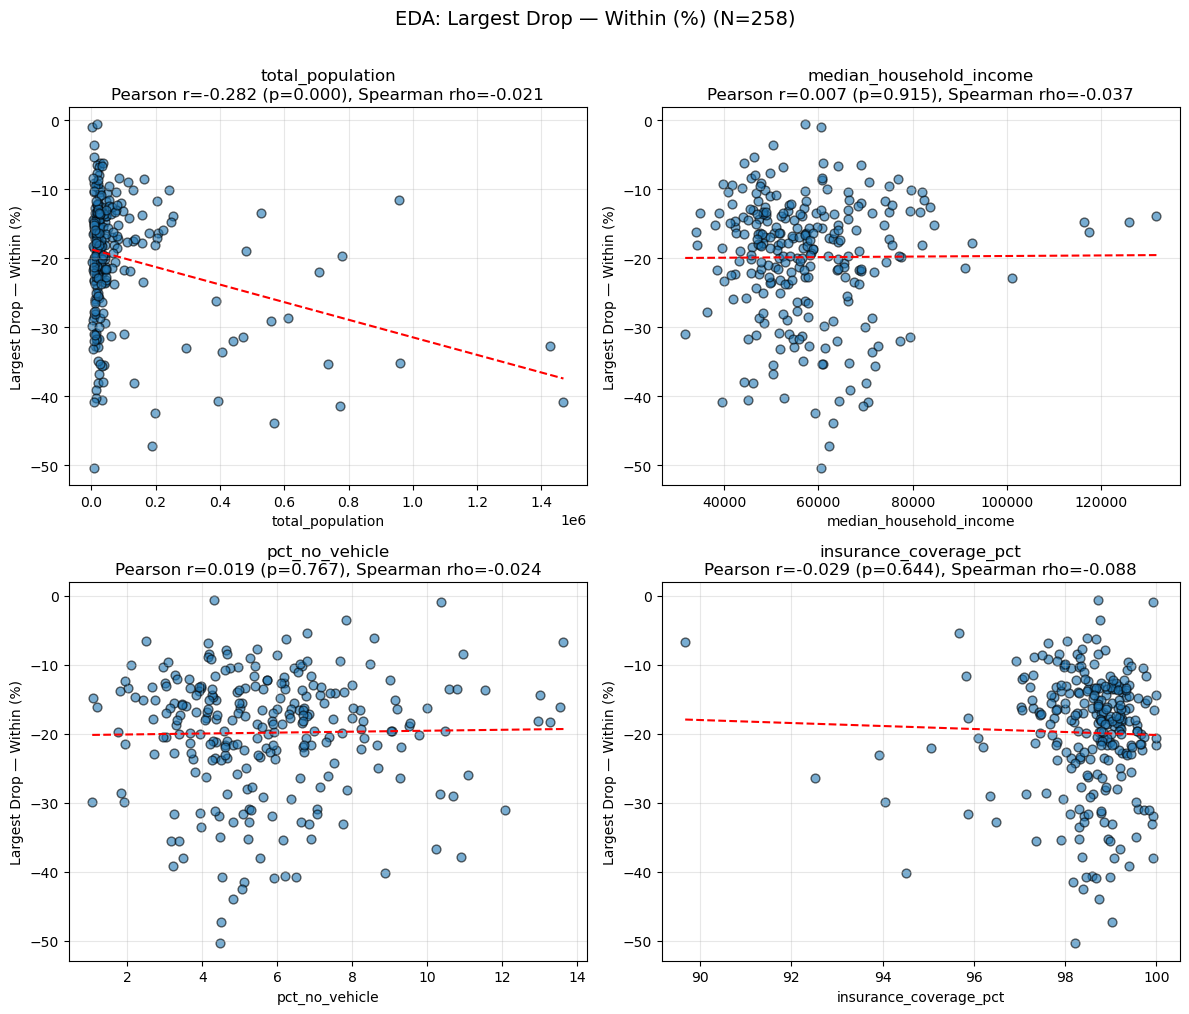

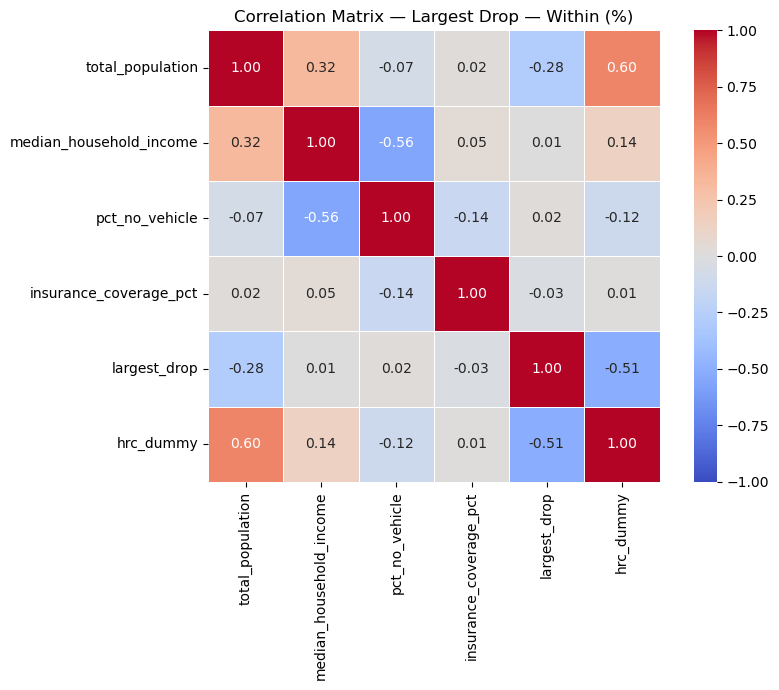

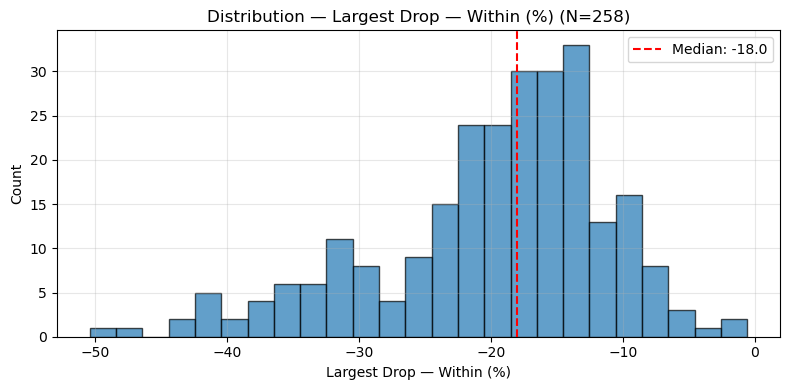


EDA: Largest Drop — Inflow (%) (244 counties)


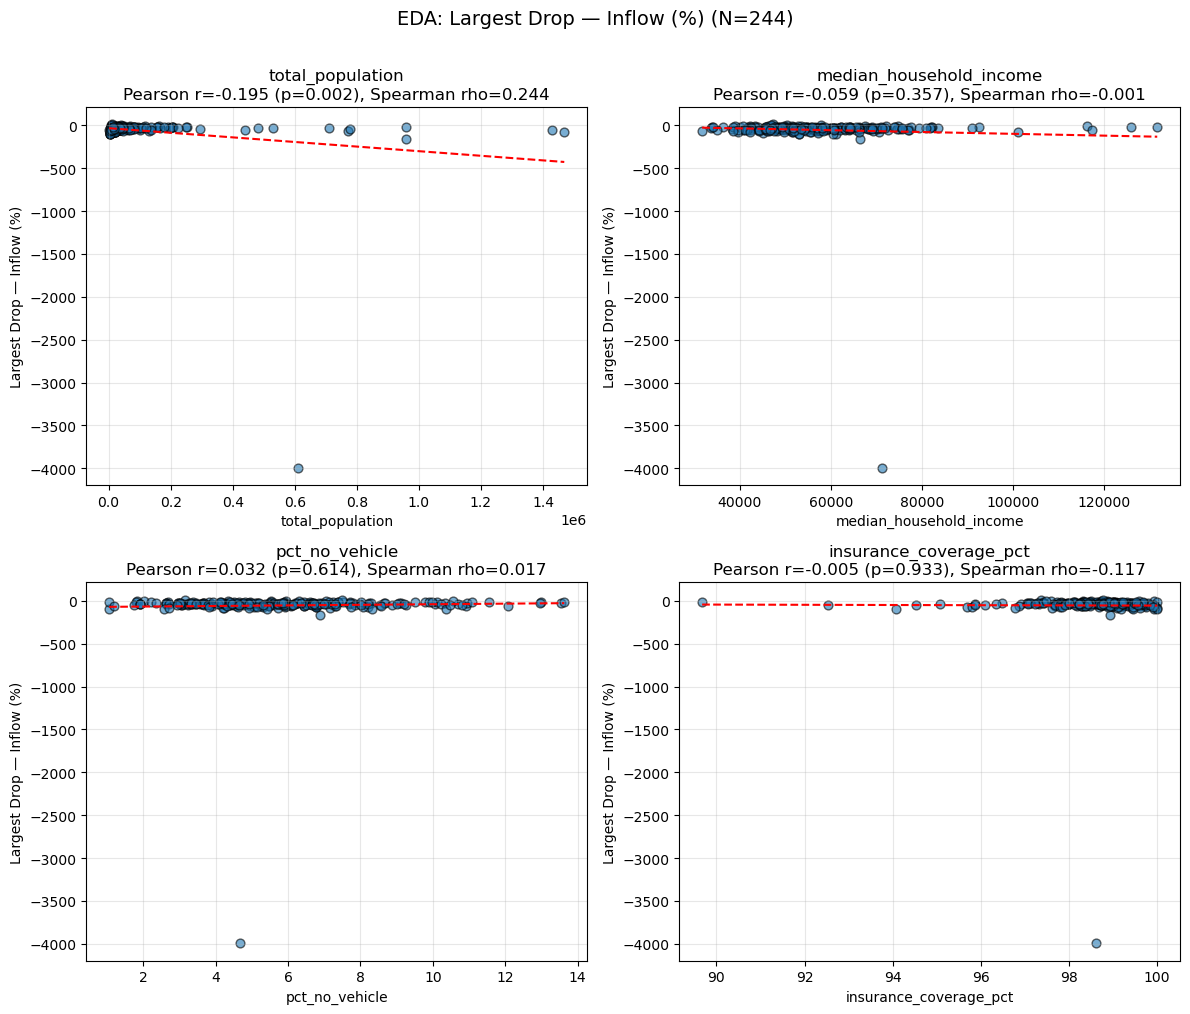

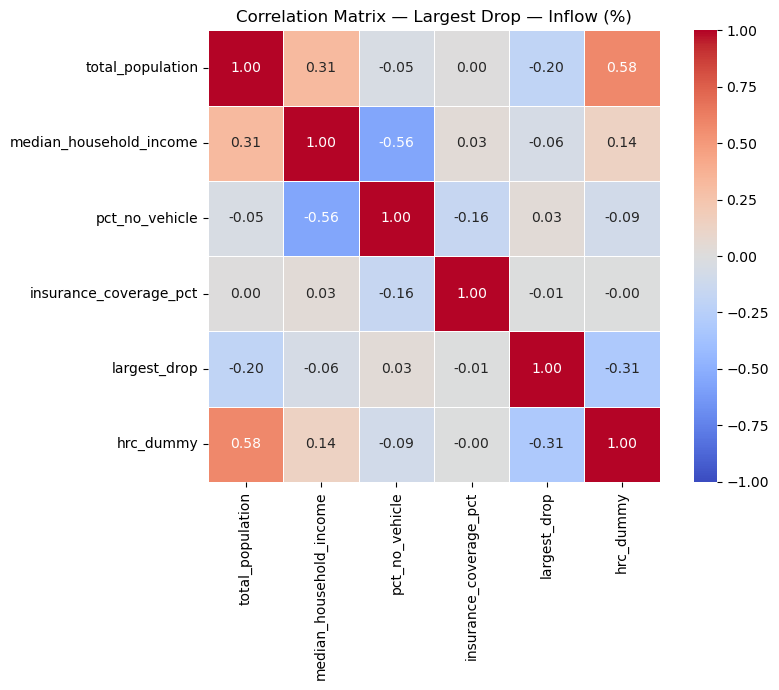

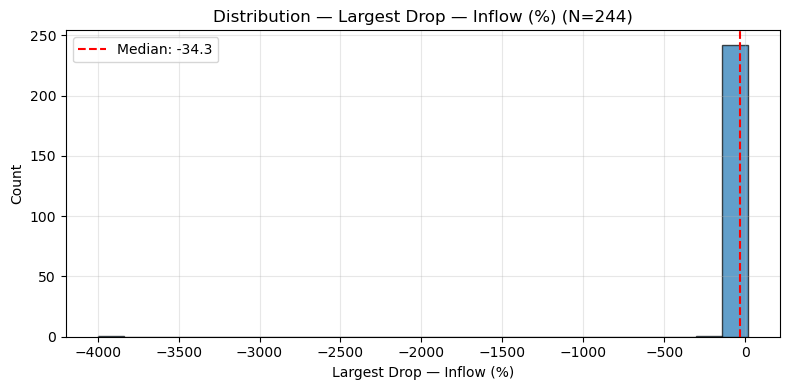


EDA: Outflow Increase (%) (21 counties)


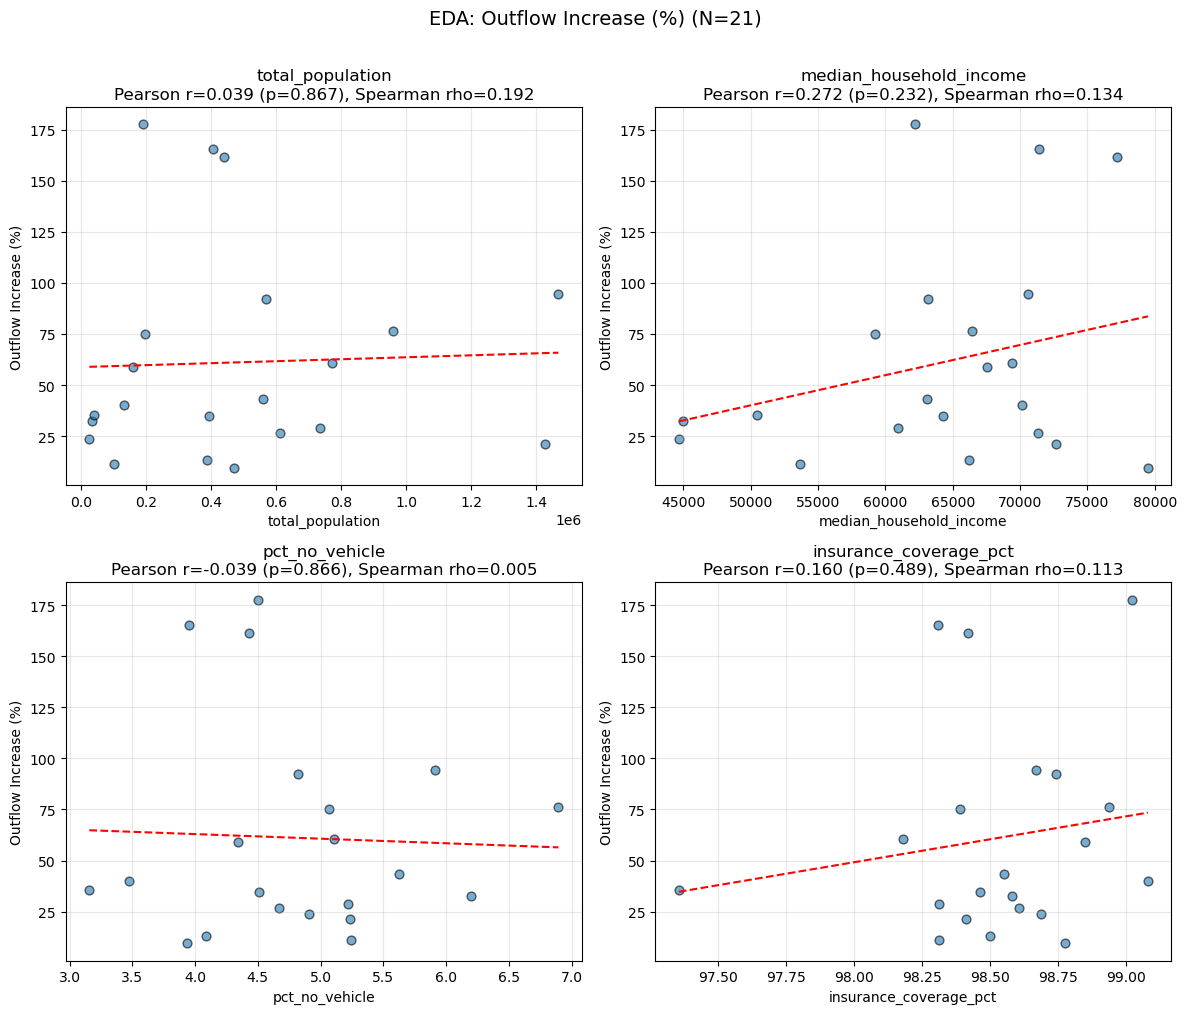

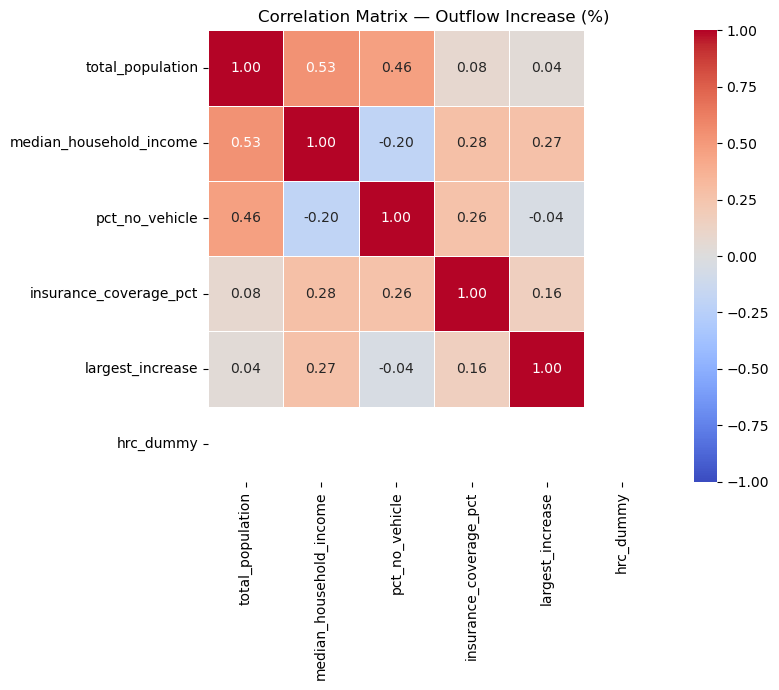

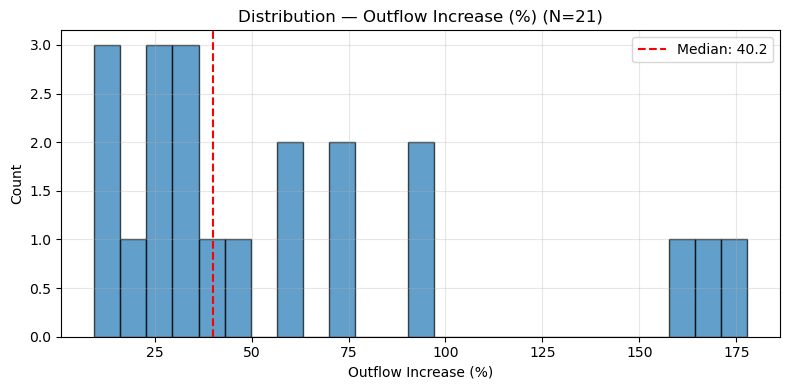


EDA: Recovery Time — Within (days) (21 counties)


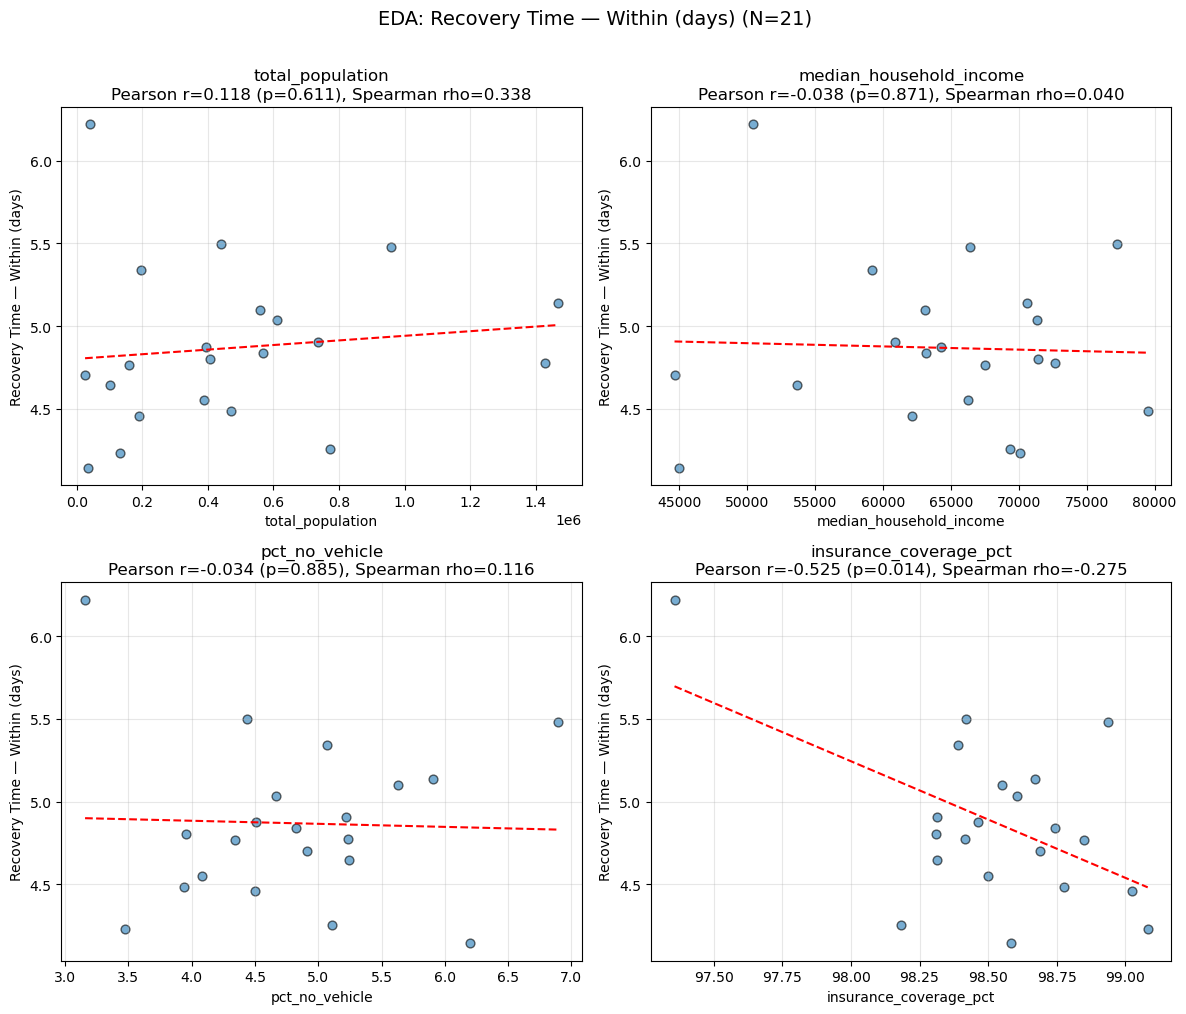

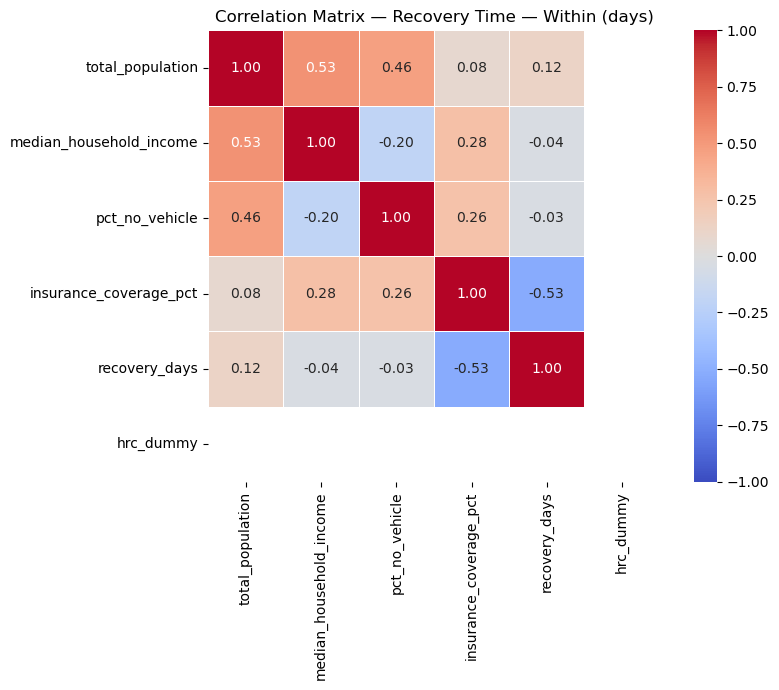

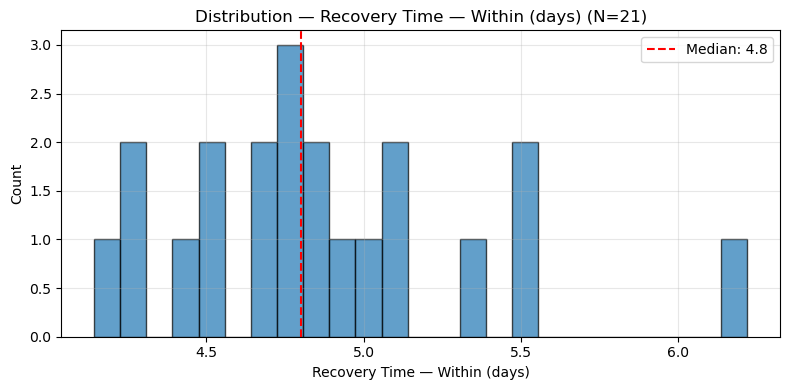


EDA: Recovery Time — Inflow (days) (9 counties)


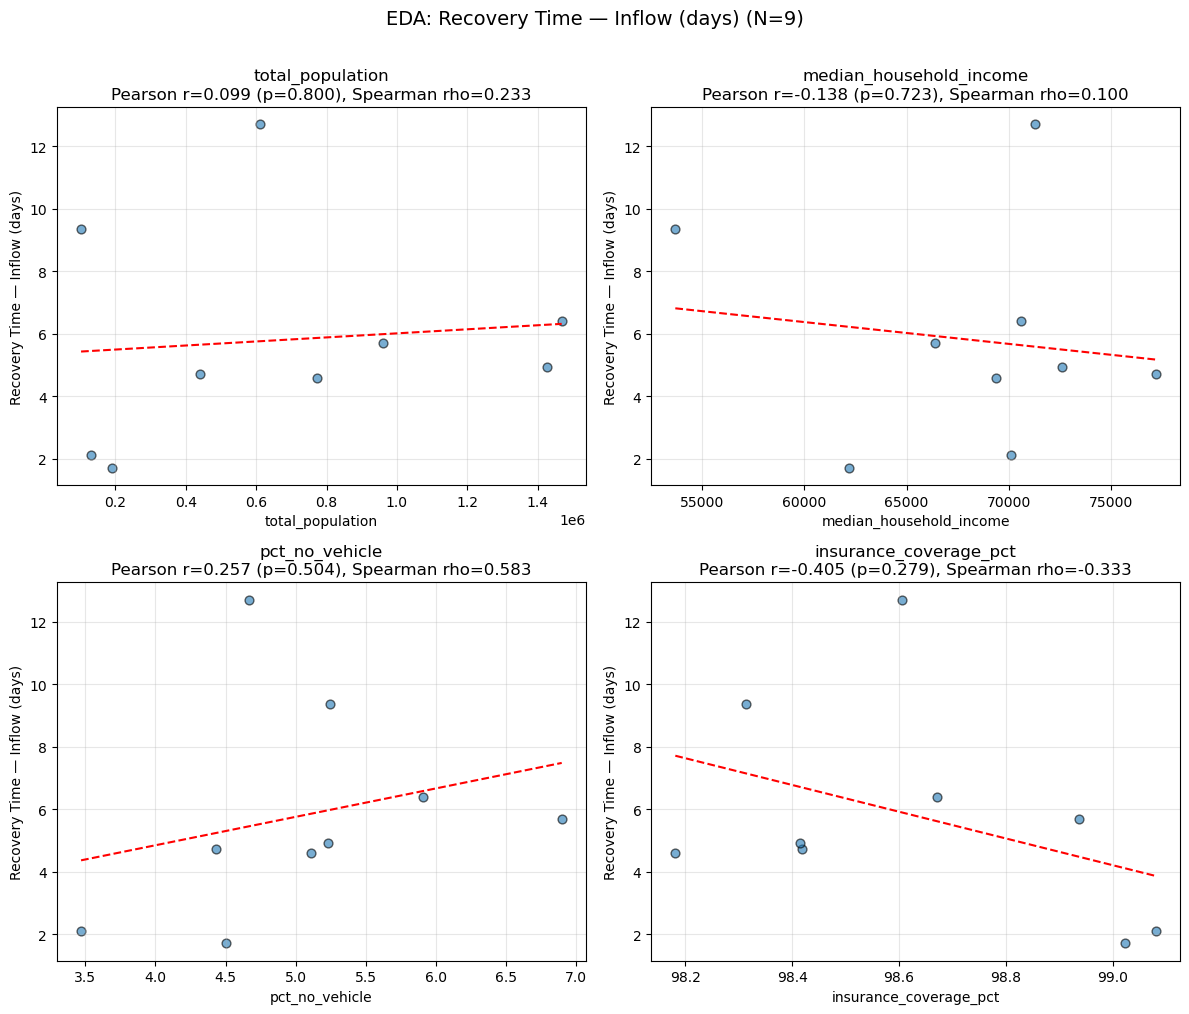

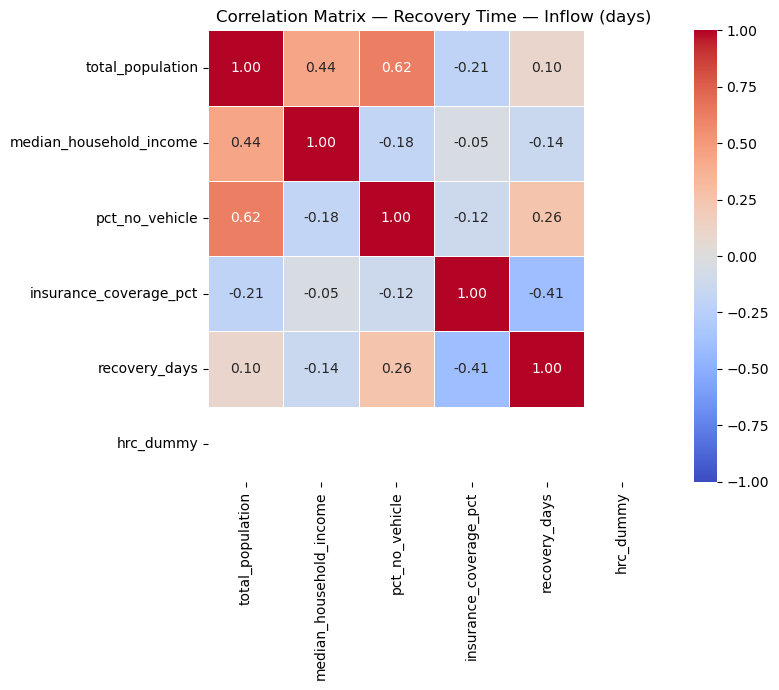

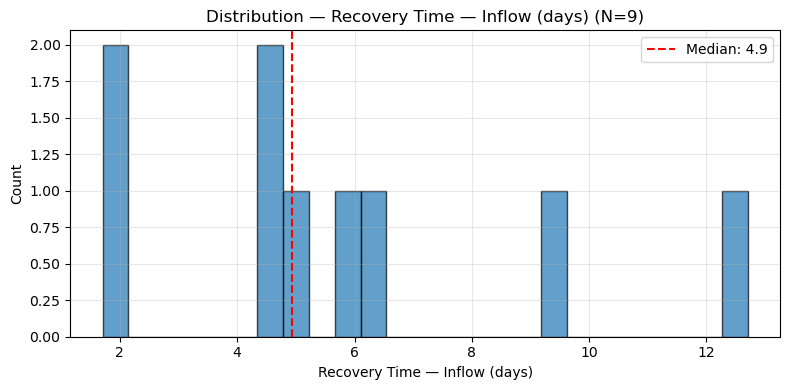

In [11]:
for dv_key, merged in merged_data.items():
    cfg = DV_CONFIGS[dv_key]
    dv_col = cfg["dv_col"]
    display_name = cfg["label"]

    if len(merged) < 5:
        print(f"Skipping EDA for {dv_key}: only {len(merged)} observations")
        continue

    print(f"\n{'='*70}")
    print(f"EDA: {display_name} ({len(merged)} counties)")
    print(f"{'='*70}")

    plot_eda_scatter(merged, FEATURES, dv_col, dv_key, display_name, OUTPUT_DIR)
    plot_correlation_matrix(merged, FEATURES, dv_col, dv_key, display_name, OUTPUT_DIR)
    plot_dv_distribution(merged, dv_col, dv_key, display_name, OUTPUT_DIR)

## 4. Pooled OLS Regression with Diagnostics

Each regression pools both hurricanes with a hurricane dummy variable (1=Milton, 0=Helene).

**Model**: `DV ~ β₀ + β₁·pop_z + β₂·income_z + β₃·novehicle_z + β₄·insurance_z + β₅·hrc_dummy + ε`

In [12]:
def compute_vif(X_df):
    """Compute Variance Inflation Factor for each feature."""
    X_const = sm.add_constant(X_df)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
    return vif_data[vif_data["Variable"] != "const"]

In [13]:
def run_pooled_regression(merged_df, features, dv_col, dv_key, display_name, output_dir):
    """
    Run OLS regression pooling both hurricanes with full diagnostics.

    Model: DV ~ intercept + socioeconomic features (standardized) + hrc_dummy (raw)

    Diagnostics: VIF, 4-panel residual plots, Breusch-Pagan, Shapiro-Wilk, Durbin-Watson.

    Returns
    -------
    model : OLS regression result
    reg_df : DataFrame used for regression (with residuals added)
    """
    all_iv_cols = features + ["hrc_dummy"]
    if len(merged_df) < len(all_iv_cols) + 2:
        print(f"Too few observations ({len(merged_df)}) for regression.")
        return None, merged_df

    X_socio = merged_df[features].copy()
    X_dummy = merged_df[["hrc_dummy"]].copy()
    y = merged_df[dv_col].copy()

    # \u2500\u2500 VIF (socioeconomic features only) \u2500\u2500
    vif_df = compute_vif(X_socio)
    print(f"\nVariance Inflation Factors (socioeconomic features):")
    display(vif_df.round(3))
    high_vif = vif_df[vif_df["VIF"] > 5]
    if len(high_vif) > 0:
        print("WARNING: High VIF detected (>5):")
        display(high_vif)

    # \u2500\u2500 Standardize socioeconomic features \u2500\u2500
    scaler = StandardScaler()
    X_socio_scaled = pd.DataFrame(
        scaler.fit_transform(X_socio),
        columns=features,
        index=X_socio.index,
    )

    # \u2500\u2500 Combine: standardized features + raw dummy \u2500\u2500
    X_all = pd.concat([X_socio_scaled, X_dummy.reset_index(drop=True)], axis=1)
    X_all.index = X_socio_scaled.index
    X_const = sm.add_constant(X_all)

    # \u2500\u2500 Fit OLS \u2500\u2500
    model = sm.OLS(y.values, X_const.values).fit()

    # Attach proper names
    iv_names = ["const"] + features + ["hrc_dummy"]

    # \u2500\u2500 Print results \u2500\u2500
    print(f"\n{'='*70}")
    print(f"Pooled OLS Regression: {display_name}")
    print(f"{'='*70}")
    print(f"N = {int(model.nobs)}")
    print(f"DV: {dv_col}")
    print(f"IVs: {features} (standardized) + hrc_dummy (raw: 1=Milton, 0=Helene)")
    print(f"R-squared: {model.rsquared:.4f}, Adj. R-squared: {model.rsquared_adj:.4f}")
    print(f"F-statistic: {model.fvalue:.4f}, Prob(F): {model.f_pvalue:.4e}")

    dw = sm.stats.stattools.durbin_watson(model.resid)
    print(f"Durbin-Watson: {dw:.4f}")

    print(f"\nCoefficients:")
    coef_table = pd.DataFrame({
        "Coefficient": model.params,
        "Std. Error": model.bse,
        "t-stat": model.tvalues,
        "p-value": model.pvalues,
    }, index=iv_names)
    display(coef_table.round(4))

    # Rebuild model with named columns for summary
    X_const_named = X_const.copy()
    X_const_named.columns = iv_names
    model_named = sm.OLS(y, X_const_named).fit()
    print("\n" + model_named.summary().as_text())

    # \u2500\u2500 Normality test \u2500\u2500
    if len(model.resid) <= 5000:
        stat_sw, p_sw = stats.shapiro(model.resid)
        print(f"\nShapiro-Wilk test: W={stat_sw:.4f}, p={p_sw:.4e}")
        if p_sw < 0.05:
            print("  -> Residuals may not be normally distributed (p < 0.05)")

    # \u2500\u2500 Breusch-Pagan test \u2500\u2500
    try:
        bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, X_const.values)
        print(f"Breusch-Pagan test: LM={bp_stat:.4f}, p={bp_p:.4e}")
        if bp_p < 0.05:
            print("  -> Heteroscedasticity detected (p < 0.05)")
    except Exception as e:
        print(f"Breusch-Pagan test failed: {e}")

    # \u2500\u2500 Diagnostic plots \u2500\u2500
    fig_dir = os.path.join(output_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Residuals vs Fitted
    axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.6,
                       edgecolors="k", s=30)
    axes[0, 0].axhline(0, color="red", linestyle="--")
    axes[0, 0].set_xlabel("Fitted Values")
    axes[0, 0].set_ylabel("Residuals")
    axes[0, 0].set_title("Residuals vs Fitted")
    axes[0, 0].grid(alpha=0.3)

    # 2. Q-Q plot
    sm.qqplot(model.resid, line="45", ax=axes[0, 1], alpha=0.6)
    axes[0, 1].set_title("Q-Q Plot of Residuals")

    # 3. Histogram of residuals
    axes[1, 0].hist(model.resid, bins=25, edgecolor="black", alpha=0.7,
                    density=True)
    x_range = np.linspace(model.resid.min(), model.resid.max(), 100)
    axes[1, 0].plot(
        x_range,
        stats.norm.pdf(x_range, model.resid.mean(), model.resid.std()),
        "r-", linewidth=2, label="Normal fit"
    )
    axes[1, 0].set_xlabel("Residuals")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].set_title("Residual Distribution")
    axes[1, 0].legend()

    # 4. Scale-Location
    std_resid = model.get_influence().resid_studentized_internal
    axes[1, 1].scatter(model.fittedvalues, np.sqrt(np.abs(std_resid)),
                       alpha=0.6, edgecolors="k", s=30)
    axes[1, 1].set_xlabel("Fitted Values")
    axes[1, 1].set_ylabel("sqrt(|Standardized Residuals|)")
    axes[1, 1].set_title("Scale-Location")
    axes[1, 1].grid(alpha=0.3)

    fig.suptitle(f"Diagnostics: {display_name}", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.savefig(
        os.path.join(fig_dir, f"regression_diagnostics_{dv_key}.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()

    # Add residuals to dataframe for downstream use
    reg_df = merged_df.copy()
    reg_df["fitted"] = model.fittedvalues
    reg_df["residuals"] = model.resid

    return model_named, reg_df

In [14]:
all_models = {}
all_reg_dfs = {}

for dv_key, merged in merged_data.items():
    cfg = DV_CONFIGS[dv_key]
    dv_col = cfg["dv_col"]
    display_name = cfg["label"]

    print(f"\n{'='*70}")
    print(f"REGRESSION: {display_name}")
    print(f"{'='*70}")

    model, reg_df = run_pooled_regression(
        merged, FEATURES, dv_col, dv_key, display_name, OUTPUT_DIR
    )

    all_models[dv_key] = model
    all_reg_dfs[dv_key] = reg_df


REGRESSION: Largest Drop — Within (%)

Variance Inflation Factors (socioeconomic features):


,Variable,VIF
1,total_population,1.138
2,median_household_income,1.656
3,pct_no_vehicle,1.521
4,insurance_coverage_pct,1.024


ValueError: Length mismatch: Expected axis has 288 elements, new values have 258 elements

## 5. Bubble Scatter Plot: DV vs Income (Color=Hurricane, Size=Population)

In [16]:
def plot_bubble_scatter(merged_df, dv_col, dv_key, display_name, unit, output_dir):
    """
    Bubble scatter: DV vs median_household_income.
    Color = hurricane (Milton=red, Helene=blue).
    Size proportional to county total_population.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # Normalize population for marker size (range 20 to 500)
    pop = merged_df["total_population"].values
    size_min, size_max = 20, 500
    pop_norm = (pop - pop.min()) / (pop.max() - pop.min() + 1e-9)
    sizes = size_min + pop_norm * (size_max - size_min)

    colors = {"milton": "#e74c3c", "helene": "#3498db"}

    for hrc_name, color in colors.items():
        mask = merged_df["hrc_name"] == hrc_name
        ax.scatter(
            merged_df.loc[mask, "median_household_income"],
            merged_df.loc[mask, dv_col],
            s=sizes[mask.values],
            c=color,
            alpha=0.6,
            edgecolors="k",
            linewidths=0.5,
            label=hrc_name.capitalize(),
        )

    ax.set_xlabel("Median Household Income ($)", fontsize=12)
    ax.set_ylabel(f"{display_name}", fontsize=12)
    ax.set_title(
        f"{display_name} vs. Income\n"
        f"(bubble size \u221d county population)",
        fontsize=13,
    )
    ax.grid(alpha=0.3)

    # Population size legend (10th, 50th, 90th percentile)
    pop_percentiles = np.percentile(pop, [10, 50, 90])
    for pval in pop_percentiles:
        s = size_min + ((pval - pop.min()) / (pop.max() - pop.min() + 1e-9)) * (size_max - size_min)
        ax.scatter([], [], s=s, c="gray", alpha=0.5, edgecolors="k",
                   linewidths=0.5, label=f"Pop {pval/1e3:.0f}k")
    ax.legend(
        title="Hurricane / Population",
        fontsize=10, title_fontsize=10,
        loc="best"
    )

    plt.tight_layout()

    fig_dir = os.path.join(output_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)
    plt.savefig(
        os.path.join(fig_dir, f"bubble_scatter_{dv_key}.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()

    print(f"\nBubble scatter \u2014 {display_name}: {len(merged_df)} counties")
    print(merged_df.groupby("hrc_name").size())


Bubble Plot: Largest Drop — Within (%)


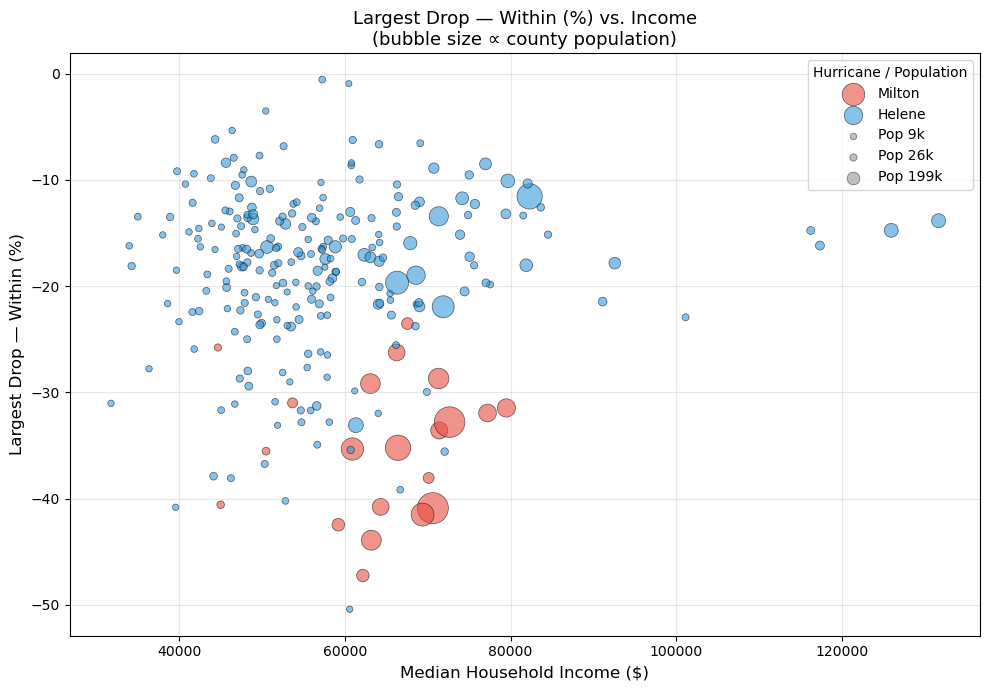


Bubble scatter — Largest Drop — Within (%): 258 counties
hrc_name
helene    237
milton     21
dtype: int64

Bubble Plot: Largest Drop — Inflow (%)


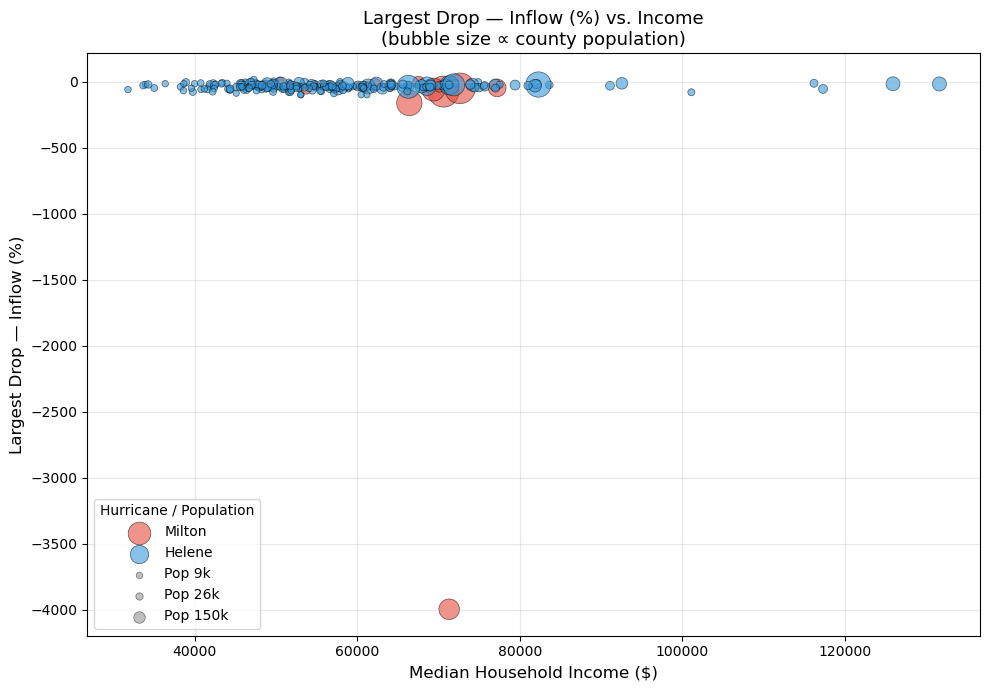


Bubble scatter — Largest Drop — Inflow (%): 244 counties
hrc_name
helene    233
milton     11
dtype: int64

Bubble Plot: Outflow Increase (%)


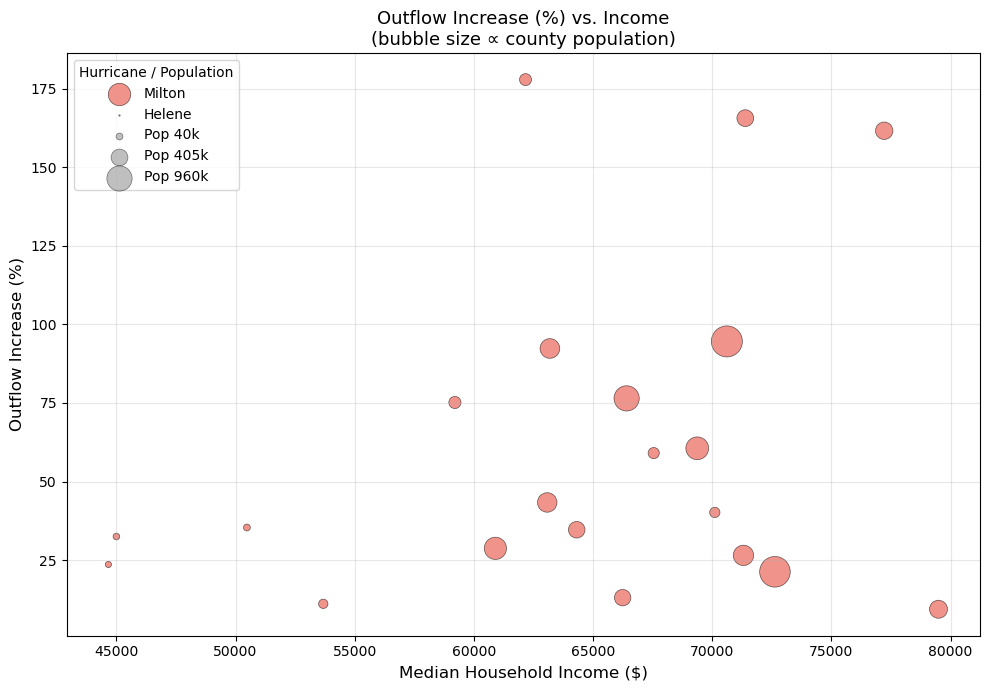


Bubble scatter — Outflow Increase (%): 21 counties
hrc_name
milton    21
dtype: int64

Bubble Plot: Recovery Time — Within (days)


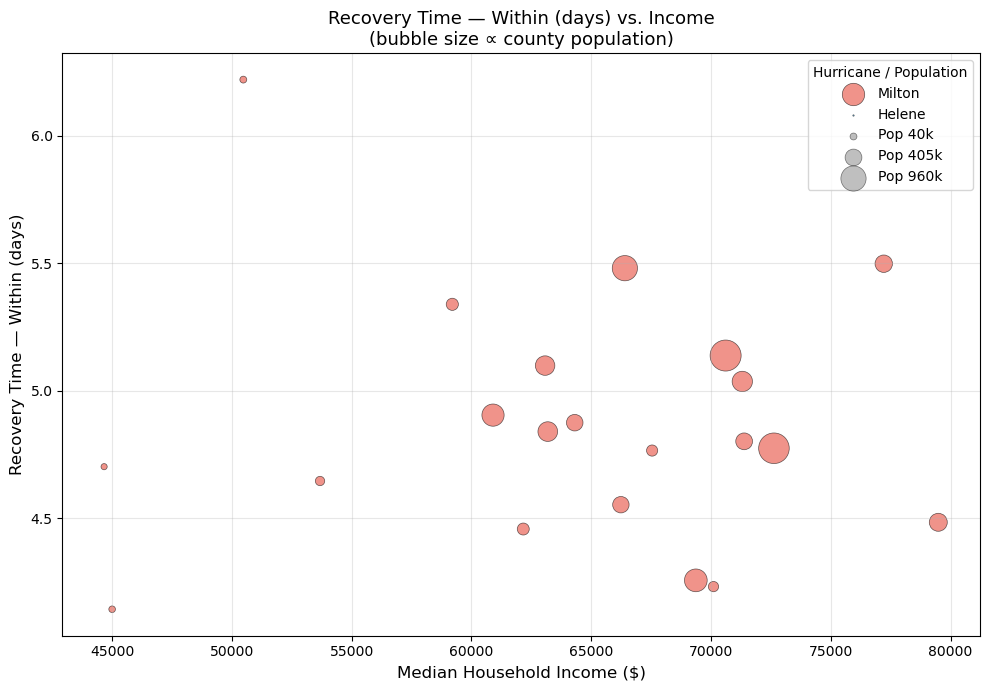


Bubble scatter — Recovery Time — Within (days): 21 counties
hrc_name
milton    21
dtype: int64

Bubble Plot: Recovery Time — Inflow (days)


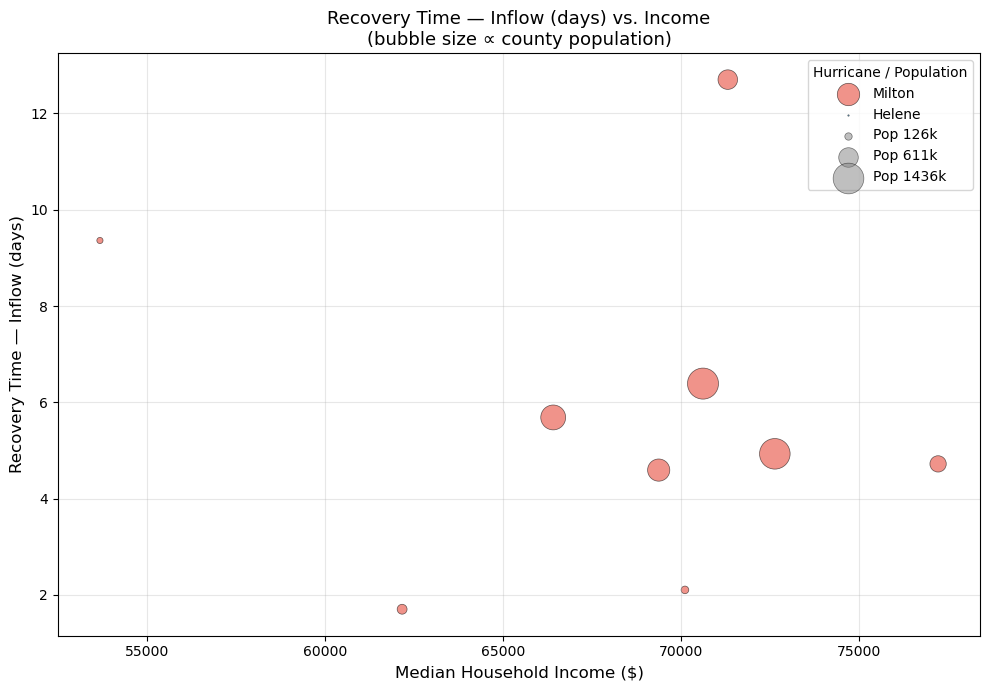


Bubble scatter — Recovery Time — Inflow (days): 9 counties
hrc_name
milton    9
dtype: int64


In [17]:
for dv_key, merged in merged_data.items():
    cfg = DV_CONFIGS[dv_key]
    dv_col = cfg["dv_col"]
    display_name = cfg["label"]
    unit = cfg["unit"]

    print(f"\n{'='*60}")
    print(f"Bubble Plot: {display_name}")
    print(f"{'='*60}")

    plot_bubble_scatter(merged, dv_col, dv_key, display_name, unit, OUTPUT_DIR)

## 6. Cross-DV Summary and Comparison

In [18]:
# ── Side-by-side coefficient comparison across all DV keys ──

iv_names = ["const"] + FEATURES + ["hrc_dummy"]

comparison_rows = []
for dv_key, model in all_models.items():
    if model is None:
        continue

    display_name = DV_CONFIGS[dv_key]["label"]

    for i, var_name in enumerate(iv_names):
        if var_name == "const":
            continue
        comparison_rows.append({
            "DV": display_name,
            "dv_key": dv_key,
            "Variable": var_name,
            "Coefficient": model.params.iloc[i],
            "Std. Error": model.bse.iloc[i],
            "p-value": model.pvalues.iloc[i],
        })

comp_df = pd.DataFrame(comparison_rows)
print("Coefficient Comparison Across DV Keys:")
display(comp_df.round(4))

# Export
comp_path = os.path.join(OUTPUT_DIR, "coefficient_comparison.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\nExported to {comp_path}")

Coefficient Comparison Across DV Keys:


""



Exported to ../results/regression/coefficient_comparison.csv


In [19]:
# ── Grouped bar chart: coefficients by DV key ──

plot_vars = FEATURES + ["hrc_dummy"]
pivot_df = comp_df.pivot(index="Variable", columns="DV", values="Coefficient")
pivot_df = pivot_df.reindex(plot_vars)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_df.plot(kind="bar", ax=ax, width=0.8, edgecolor="black", linewidth=0.5)

ax.set_ylabel("Coefficient (standardized for socioeconomic, raw for dummy)", fontsize=11)
ax.set_xlabel("Variable", fontsize=11)
ax.set_title("Coefficient Comparison Across Dependent Variables", fontsize=14)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.legend(title="Dependent Variable", fontsize=9, title_fontsize=10,
          bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "figures", "coefficient_comparison_barplot.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {fig_path}")

KeyError: 'Variable'

In [20]:
# ── Model summary table ──

summary_rows = []
for dv_key, model in all_models.items():
    if model is None:
        continue

    display_name = DV_CONFIGS[dv_key]["label"]
    merged = merged_data[dv_key]

    summary_rows.append({
        "DV": display_name,
        "dv_key": dv_key,
        "N": int(model.nobs),
        "Milton_N": int((merged["hrc_name"] == "milton").sum()),
        "Helene_N": int((merged["hrc_name"] == "helene").sum()),
        "R\u00b2": round(model.rsquared, 4),
        "Adj. R\u00b2": round(model.rsquared_adj, 4),
        "F-stat": round(model.fvalue, 4),
        "Prob(F)": f"{model.f_pvalue:.4e}",
    })

summary_df = pd.DataFrame(summary_rows)
print("Model Summary Comparison:")
display(summary_df)

summary_path = os.path.join(OUTPUT_DIR, "model_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nExported to {summary_path}")

Model Summary Comparison:


""



Exported to ../results/regression/model_summary.csv


## 7. Final Results Export

In [21]:
def export_regression_results(model, dv_key, display_name, features, output_dir):
    """
    Export OLS summary (TXT) and coefficient table (CSV).
    """
    os.makedirs(output_dir, exist_ok=True)

    if model is None:
        print(f"No model for {dv_key}, skipping export.")
        return

    dv_col = DV_CONFIGS[dv_key]["dv_col"]

    # Text summary
    txt_path = os.path.join(output_dir, f"regression_{dv_key}.txt")
    with open(txt_path, "w") as f:
        f.write(f"Pooled OLS Regression: {display_name}\n")
        f.write(f"N = {int(model.nobs)}\n")
        f.write(f"DV: {dv_col}\n")
        f.write(f"IVs: {features} (standardized) + hrc_dummy (raw: 1=Milton, 0=Helene)\n\n")
        f.write(model.summary().as_text())
    print(f"Exported regression summary to {txt_path}")

    # Coefficient CSV
    coef_df = pd.DataFrame({
        "variable": model.params.index.tolist(),
        "coefficient": model.params.values,
        "std_error": model.bse.values,
        "t_stat": model.tvalues.values,
        "p_value": model.pvalues.values,
    })
    coef_path = os.path.join(output_dir, f"regression_coefficients_{dv_key}.csv")
    coef_df.to_csv(coef_path, index=False)
    print(f"Exported coefficients to {coef_path}")

In [22]:
for dv_key, model in all_models.items():
    display_name = DV_CONFIGS[dv_key]["label"]
    export_regression_results(model, dv_key, display_name, FEATURES, OUTPUT_DIR)

In [23]:
# ── Final summary ──

print("=" * 70)
print("EXPORTED FILES SUMMARY")
print("=" * 70)
print(f"\nOutput directory: {OUTPUT_DIR}")

# List CSV/TXT files
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname == "figures":
        continue
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  {fname:50s} {size_kb:>6.1f} KB")

# List figures
fig_dir = os.path.join(OUTPUT_DIR, "figures")
if os.path.isdir(fig_dir):
    figs = sorted([f for f in os.listdir(fig_dir) if f.endswith(".png")])
    print(f"\nfigures/: {len(figs)} PNG files")
    for fig_name in figs:
        print(f"  {fig_name}")

print(f"\n{'='*70}")
print(f"Notebook v2b complete.")
print(f"{'='*70}")
print(f"\nProcessed {len(all_models)} DV keys:")
for dv_key, model in all_models.items():
    if model is not None:
        n = int(model.nobs)
        r2 = model.rsquared
        print(f"  {dv_key:30s} N={n:>3d}, R\u00b2={r2:.4f}")
    else:
        print(f"  {dv_key:30s} SKIPPED (no model)")

EXPORTED FILES SUMMARY

Output directory: ../results/regression/
  coefficient_comparison.csv                            0.0 KB
  model_summary.csv                                     0.0 KB

figures/: 20 PNG files
  bubble_scatter_largest_drop_inflow.png
  bubble_scatter_largest_drop_within.png
  bubble_scatter_outflow_increase.png
  bubble_scatter_recovery_inflow.png
  bubble_scatter_recovery_within.png
  correlation_matrix_largest_drop_inflow.png
  correlation_matrix_largest_drop_within.png
  correlation_matrix_outflow_increase.png
  correlation_matrix_recovery_inflow.png
  correlation_matrix_recovery_within.png
  distribution_largest_drop_inflow.png
  distribution_largest_drop_within.png
  distribution_outflow_increase.png
  distribution_recovery_inflow.png
  distribution_recovery_within.png
  eda_scatter_largest_drop_inflow.png
  eda_scatter_largest_drop_within.png
  eda_scatter_outflow_increase.png
  eda_scatter_recovery_inflow.png
  eda_scatter_recovery_within.png

Notebook v2b 